# 02. 데이터 전처리 - 문서 파싱 및 텍스트 추출

## 파싱 전략
- **메인 파서**: `kordoc` (Node.js CLI) — 마크다운 구조 출력, LLM 입력에 최적
- **교차 검증**: `hwp-hwpx-parser` (HWP), `pdfplumber` (PDF) — 누락/품질 비교

## 파이프라인
1. 메타데이터 로딩
2. kordoc으로 전체 문서 일괄 파싱 (마크다운)
3. Python 파서로 교차 검증
4. 파싱 결과 비교 및 품질 확인
5. 메타데이터 + 본문 결합 후 저장

> **Input**: `data/raw/rfp/` (101개 HWP/PDF/DOCX)  
> **Output**: `data/processed/parsed_documents.parquet`  
> **Prev**: [01_eda.ipynb](01_eda.ipynb) | **Next**: [03_cleaning.ipynb](03_cleaning.ipynb)


In [1]:
import pandas as pd
import subprocess
import json
import time
from pathlib import Path
from hwp_hwpx_parser import HWP5Reader
import pdfplumber

In [2]:
BASE_DIR = Path("../../data/raw")
METADATA_PATH = BASE_DIR / "metadata" / "data_list.csv"
RFP_DIR = BASE_DIR / "rfp"
OUTPUT_DIR = Path("../../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

KORDOC_BIN = Path.home() / ".npm-global" / "bin" / "kordoc"
print(f"kordoc 경로: {KORDOC_BIN} (exists: {KORDOC_BIN.exists()})")

kordoc 경로: /home/user1/.npm-global/bin/kordoc (exists: True)


## 1. 메타데이터 로딩

In [3]:
df = pd.read_csv(METADATA_PATH, encoding='utf-8-sig')
print(f"총 {len(df)}건")
print(f"파일형식: {df['파일형식'].value_counts().to_dict()}")
df[['사업명', '발주 기관', '파일형식', '파일명']].head()

총 100건
파일형식: {'hwp': 96, 'pdf': 4}


,사업명,발주 기관,파일형식,파일명
0,한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화,한영대학,hwp,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp
1,2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선,한국연구재단,hwp,한국연구재단_2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선.hwp
2,EIP3.0 고압가스 안전관리 시스템 구축 용역,한국생산기술연구원,hwp,한국생산기술연구원_EIP3.0 고압가스 안전관리 시스템 구축 용역.hwp
3,도시계획위원회 통합관리시스템 구축용역,인천광역시,hwp,인천광역시_도시계획위원회 통합관리시스템 구축용역.hwp
4,봉화군 재난통합관리시스템 고도화 사업(협상)(긴급),경상북도 봉화군,hwp,경상북도 봉화군_봉화군 재난통합관리시스템 고도화 사업(협상)(긴급).hwp


## 2. kordoc 파싱 함수 정의

In [4]:
def parse_with_kordoc(file_path: str | Path, timeout: int = 120) -> dict:
    """kordoc CLI로 문서를 파싱하여 마크다운 텍스트를 반환한다."""
    file_path = Path(file_path)
    try:
        result = subprocess.run(
            [str(KORDOC_BIN), str(file_path)],
            capture_output=True,
            text=True,
            timeout=timeout,
        )
        text = result.stdout.strip()
        return {
            "파일명": file_path.name,
            "파서": "kordoc",
            "텍스트": text,
            "글자수": len(text),
            "성공": len(text) > 0,
            "에러": None,
        }
    except subprocess.TimeoutExpired:
        return {
            "파일명": file_path.name,
            "파서": "kordoc",
            "텍스트": "",
            "글자수": 0,
            "성공": False,
            "에러": "timeout",
        }
    except Exception as e:
        return {
            "파일명": file_path.name,
            "파서": "kordoc",
            "텍스트": "",
            "글자수": 0,
            "성공": False,
            "에러": str(e),
        }

## 3. Python 파서 함수 정의 (교차 검증용)

In [5]:
def parse_hwp_with_python(file_path: str | Path) -> dict:
    """hwp-hwpx-parser로 HWP 텍스트를 추출한다."""
    file_path = Path(file_path)
    try:
        reader = HWP5Reader(str(file_path))
        text = reader.extract_text()
        tables = reader.get_tables()
        reader.close()
        return {
            "파일명": file_path.name,
            "파서": "hwp-hwpx-parser",
            "텍스트": text,
            "글자수": len(text),
            "표_수": len(tables),
            "성공": True,
            "에러": None,
        }
    except Exception as e:
        return {
            "파일명": file_path.name,
            "파서": "hwp-hwpx-parser",
            "텍스트": "",
            "글자수": 0,
            "표_수": 0,
            "성공": False,
            "에러": str(e),
        }


def parse_pdf_with_python(file_path: str | Path) -> dict:
    """pdfplumber로 PDF 텍스트를 추출한다."""
    file_path = Path(file_path)
    try:
        with pdfplumber.open(str(file_path)) as pdf:
            pages = []
            for page in pdf.pages:
                text = page.extract_text() or ""
                pages.append(text)
            full_text = "\n".join(pages)
            return {
                "파일명": file_path.name,
                "파서": "pdfplumber",
                "텍스트": full_text,
                "글자수": len(full_text),
                "페이지수": len(pdf.pages),
                "성공": True,
                "에러": None,
            }
    except Exception as e:
        return {
            "파일명": file_path.name,
            "파서": "pdfplumber",
            "텍스트": "",
            "글자수": 0,
            "페이지수": 0,
            "성공": False,
            "에러": str(e),
        }

## 4. 단건 테스트 — 파서별 출력 확인

전체 일괄 파싱 전에 샘플 1건으로 kordoc 출력 형태를 확인합니다.

In [6]:
sample_file = RFP_DIR / df.loc[1, '파일명']  # 두 번째 문서
print(f"테스트 파일: {sample_file.name}\n")

# kordoc
kordoc_result = parse_with_kordoc(sample_file)
print(f"[kordoc] {kordoc_result['글자수']}자, 성공={kordoc_result['성공']}")
print(kordoc_result['텍스트'][:1000])
print("...\n")

# hwp-hwpx-parser
hwp_result = parse_hwp_with_python(sample_file)
print(f"[hwp-hwpx-parser] {hwp_result['글자수']}자, 표 {hwp_result['표_수']}개")
print(hwp_result['텍스트'][:1000])

테스트 파일: 한국연구재단_2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선.hwp



[kordoc] 103640자, 성공=True
| 제 안 요 청 서<br>[ 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선 ] | 제 안 요 청 서<br>[ 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선 ] | 제 안 요 청 서<br>[ 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선 ] |  |
| --- | --- | --- | --- |


# 2024. 10.

| 담 당 | 부서명 | 성 명 | 전 화 |
| --- | --- | --- | --- |
| 사업관련 | 학술데이터분석팀 | 한민아 | 042-869-6672 |
| 계약관련 | 운영지원팀 | 이현우 | 042-869-6232 |

이 자료는 한국연구재단 제안서 작성 이외의 목적으로 복제, 전달 및 사용을 금함


### 첨부서식	92

|  | 제안요청서 |
| --- | --- |

| Ⅰ |  | 사업 개요 |
| --- | --- | --- |


# 1. 사업명: 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선


# 2. 추진배경 및 필요성


### □ 한국연구재단법 제5조, 산업교육진흥 및 산학연협력촉진에 관한 법률 제39조의2 및 제43조에 따라 실시하는 대학 산학협력활동 실태조사를 안정적으로 운영 필요


### □ 항목 지침 변경사항 등 변화에 신속하고 정확하게 대응하며, 기능개선에 대한 사용자 요구를 반영하여 사용자 편의성 강화 필요


#
...

[hwp-hwpx-parser] 79083자, 표 136개

|  | [IMAGE] |
| --- | --- |
|  |
|  |

[IMAGE]

|  |  |  |
| --- | --- | --- |
| 제 안 요 청 서 [ 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선 ] |  |
|  |  |
|  |  |  |

2024.  10.

| 담 당 | 부  서  명 | 성  명 | 전    화 |
| --- | --- | --- | -

## 5. kordoc 전체 일괄 파싱 (메인)

메타데이터에 등록된 100건 + 폴더에만 있는 docx 1건을 모두 파싱합니다.

In [7]:
all_files = sorted(RFP_DIR.iterdir())
print(f"파싱 대상: {len(all_files)}개 파일\n")

kordoc_results = []
start = time.time()

for i, fpath in enumerate(all_files):
    result = parse_with_kordoc(fpath)
    kordoc_results.append(result)
    status = "OK" if result['성공'] else f"FAIL ({result['에러']})"
    if (i + 1) % 10 == 0 or not result['성공']:
        print(f"  [{i+1:3d}/{len(all_files)}] {status:6s} | {result['글자수']:>7,}자 | {fpath.name[:50]}")

elapsed = time.time() - start
print(f"\n완료: {elapsed:.1f}초 ({elapsed/len(all_files):.1f}초/파일)")

파싱 대상: 101개 파일

  [ 10/101] OK     | 103,048자 | 경기도사회서비스원_2024년 통합사회정보시스템 운영지원.hwp
  [ 20/101] OK     |  77,836자 | 국립인천해양박물관_국립인천해양박물관 해양자료관리시스템 구축 용.hwp
  [ 30/101] OK     |  75,018자 | 대검찰청_아태 사이버범죄 역량강화 허브(APC-HUB) 홈페이지 및 온라인 교.hwp
  [ 40/101] OK     | 127,076자 | 서영대학교 산학협력단_전문대학 혁신지원사업 서영대학교 차세대 교육.hwp
  [ 50/101] OK     |  75,182자 | 인천공항운영서비스(주)_인천공항운영서비스㈜ 차세대 ERP시스템 구축 .hwp
  [ 60/101] OK     | 140,319자 | 전북대학교_JST 공유대학(원) xAPI기반 LRS시스템 구축.hwp
  [ 70/101] OK     |  66,045자 | 한국교육과정평가원_국가교육과정정보센터(NCIC) 시스템 운영 및 개선.hwp
  [ 80/101] OK     | 160,904자 | 한국산업단지공단_산단 안전정보시스템 1차 구축 용역.hwp
  [ 90/101] OK     |  81,667자 | 한국연구재단_2024년 기초학문자료센터 시스템 운영 및 연구성과물 DB구.hwp
  [100/101] OK     |  76,630자 | 한국해양조사협회_2024년 항해용 간행물 품질관리 업무보조 시스템 구축.hwp

완료: 98.8초 (1.0초/파일)


In [8]:
kordoc_df = pd.DataFrame(kordoc_results)

summary = pd.DataFrame({
    '지표': ['전체', '성공', '실패', '평균 글자수', '중앙값 글자수', '최소', '최대'],
    '값': [
        f"{len(kordoc_df)}건",
        f"{kordoc_df['성공'].sum()}건",
        f"{(~kordoc_df['성공']).sum()}건",
        f"{kordoc_df['글자수'].mean():,.0f}자",
        f"{kordoc_df['글자수'].median():,.0f}자",
        f"{kordoc_df['글자수'].min():,}자",
        f"{kordoc_df['글자수'].max():,}자",
    ],
}).set_index('지표')

display(summary)

failed = kordoc_df[~kordoc_df['성공']]
if len(failed):
    print(f"\n실패 목록:")
    display(failed[['파일명', '에러']])


,값
지표,
전체,101건
성공,101건
실패,0건
평균 글자수,"106,018자"
중앙값 글자수,"93,114자"
최소,"46,953자"
최대,"299,638자"


## 6. Python 파서 교차 검증 (선택)

kordoc 전체 성공 시 이 섹션은 **스킵해도 됩니다.**  
kordoc 실패 건이 있거나, 파싱 품질을 비교하고 싶을 때만 실행하세요.


In [9]:
SKIP_CROSS_VALIDATION = True  # kordoc 전체 성공 시 True로 스킵

if SKIP_CROSS_VALIDATION:
    print("교차 검증 스킵 (kordoc 101건 전체 성공)")
    python_df = pd.DataFrame(columns=['파일명', '글자수', '성공'])
else:
    import signal

    class ParseTimeout(Exception):
        pass

    def _timeout_handler(signum, frame):
        raise ParseTimeout()

    python_results = []
    for i, fpath in enumerate(sorted(RFP_DIR.iterdir())):
        ext = fpath.suffix.lower()
        if ext == '.docx':
            continue
        signal.signal(signal.SIGALRM, _timeout_handler)
        signal.alarm(60)
        try:
            if ext == '.hwp':
                result = parse_hwp_with_python(fpath)
            elif ext == '.pdf':
                result = parse_pdf_with_python(fpath)
            else:
                signal.alarm(0)
                continue
            signal.alarm(0)
        except ParseTimeout:
            signal.alarm(0)
            result = {
                "파일명": fpath.name, "파서": "timeout",
                "텍스트": "", "글자수": 0, "성공": False, "에러": "60초 타임아웃",
            }
        python_results.append(result)
        status = "OK" if result['성공'] else "FAIL"
        if (i + 1) % 20 == 0 or not result['성공']:
            print(f"  [{i+1:3d}] {status:4s} | {result['글자수']:>7,}자 | {fpath.name[:50]}")

    python_df = pd.DataFrame(python_results)
    print(f"성공: {python_df['성공'].sum()}, 실패: {(~python_df['성공']).sum()}")


교차 검증 스킵 (kordoc 101건 전체 성공)


In [10]:
if not SKIP_CROSS_VALIDATION and len(python_df) > 0:
    compare = kordoc_df[['파일명', '글자수']].merge(
        python_df[['파일명', '글자수']], on='파일명',
        suffixes=('_kordoc', '_python'), how='inner',
    )
    compare['비율(%)'] = (compare['글자수_kordoc'] / compare['글자수_python'].clip(lower=1) * 100).round(1)
    print(f"kordoc 평균: {compare['글자수_kordoc'].mean():,.0f}자")
    print(f"Python 평균: {compare['글자수_python'].mean():,.0f}자")
    print(f"비율 평균: {compare['비율(%)'].mean():.1f}%")
else:
    print("교차 검증 스킵됨 — 비교 생략")


교차 검증 스킵됨 — 비교 생략


## 7. CSV 텍스트 vs kordoc 비교

기존 CSV의 텍스트 컬럼과 kordoc 파싱 결과를 비교합니다.

In [11]:
csv_compare = df[['파일명', '사업명']].copy()
csv_compare['CSV_글자수'] = df['텍스트'].fillna('').str.len()
csv_compare = csv_compare.merge(
    kordoc_df[['파일명', '글자수']].rename(columns={'글자수': 'kordoc_글자수'}),
    on='파일명', how='left',
)
csv_compare['배수'] = (csv_compare['kordoc_글자수'] / csv_compare['CSV_글자수'].clip(lower=1)).round(1)

# 요약 통계 테이블
summary = pd.DataFrame({
    '지표': ['문서 수', '평균 글자수', '중앙값 글자수', '최소', '최대'],
    'CSV 텍스트': [
        f"{len(csv_compare)}건",
        f"{csv_compare['CSV_글자수'].mean():,.0f}자",
        f"{csv_compare['CSV_글자수'].median():,.0f}자",
        f"{csv_compare['CSV_글자수'].min():,}자",
        f"{csv_compare['CSV_글자수'].max():,}자",
    ],
    'kordoc 파싱': [
        f"{len(csv_compare)}건",
        f"{csv_compare['kordoc_글자수'].mean():,.0f}자",
        f"{csv_compare['kordoc_글자수'].median():,.0f}자",
        f"{csv_compare['kordoc_글자수'].min():,}자",
        f"{csv_compare['kordoc_글자수'].max():,}자",
    ],
}).set_index('지표')

display(summary)
print(f"\n평균 개선 배수: {csv_compare['배수'].mean():.1f}배")


,CSV 텍스트,kordoc 파싱
지표,,
문서 수,100건,100건
평균 글자수,"3,844자","106,566자"
중앙값 글자수,"2,583자","93,114자"
최소,89자,"46,953자"
최대,"18,335자","299,638자"



평균 개선 배수: 93.5배


In [12]:
# 개선 배수 Top 10 (DataFrame으로 표시)
top10 = csv_compare.nlargest(10, '배수')[['사업명', 'CSV_글자수', 'kordoc_글자수', '배수']].copy()
top10.columns = ['사업명', 'CSV (자)', 'kordoc (자)', '배수']
top10 = top10.reset_index(drop=True)
top10.index = top10.index + 1
top10.index.name = '순위'
display(top10)

print("\n-> CSV에서 89자였던 문서가 kordoc으로 78,583자 추출 (1,079배 개선)")
print("   CSV 텍스트만으로 RAG를 구축했다면 대부분의 질문에 답변 불가")


,사업명,CSV (자),kordoc (자),배수
순위,,,,
1,JST 공유대학(원) xAPI기반 LRS시스템 구축,130,140319,1079.4
2,2024년 건설기술에 관한 특허·실용신안 활용실적 관리시스템 개편 용역,89,78583,883.0
3,[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차 고도화 용역,220,175530,797.9
4,EIP3.0 고압가스 안전관리 시스템 구축 용역,234,172795,738.4
5,2025 구미아시아육상경기선수권대회 종합정보시스템 및 홈페이지 등 구축 용역,186,92534,497.5
6,스포츠윤리센터 LMS(학습지원시스템) 기능개선,298,102295,343.3
7,2024년 벤처확인종합관리시스템 기능 고도화 용역사업 입찰공고,533,156122,292.9
8,IP-NAVI 해외지식재산센터 사업관리 시스템 기능개선,549,135265,246.4
9,사업장 사회보험료 지원 고시 개정에 따른 정보시스템 보완 개발,401,91074,227.1



-> CSV에서 89자였던 문서가 kordoc으로 78,583자 추출 (1,079배 개선)
   CSV 텍스트만으로 RAG를 구축했다면 대부분의 질문에 답변 불가


## 8. 메타데이터 + 파싱 결과 결합 및 저장

kordoc 파싱 결과를 메인으로 사용하고, 메타데이터와 결합하여 저장합니다.

In [13]:
# kordoc 텍스트를 메인으로 사용
parsed_df = df.copy()
kordoc_text_map = dict(zip(kordoc_df['파일명'], kordoc_df['텍스트']))
parsed_df['본문_마크다운'] = parsed_df['파일명'].map(kordoc_text_map)
parsed_df['본문_글자수'] = parsed_df['본문_마크다운'].fillna('').str.len()

# kordoc 실패 시 CSV 텍스트로 폴백
fallback_mask = parsed_df['본문_글자수'] == 0
if fallback_mask.any():
    print(f"kordoc 실패 → CSV 폴백: {fallback_mask.sum()}건")
    parsed_df.loc[fallback_mask, '본문_마크다운'] = parsed_df.loc[fallback_mask, '텍스트']
    parsed_df.loc[fallback_mask, '본문_글자수'] = parsed_df.loc[fallback_mask, '본문_마크다운'].str.len()

print(f"\n최종 데이터: {len(parsed_df)}건")
print(f"본문 글자수 통계:")
print(parsed_df['본문_글자수'].describe().round(0))


최종 데이터: 100건
본문 글자수 통계:
count       100.0
mean     106566.0
std       44028.0
min       46953.0
25%       76476.0
50%       93114.0
75%      127148.0
max      299638.0
Name: 본문_글자수, dtype: float64


In [14]:
# 저장할 컬럼 선택
save_cols = [
    '공고 번호', '공고 차수', '사업명', '사업 금액', '발주 기관',
    '공개 일자', '입찰 참여 시작일', '입찰 참여 마감일',
    '사업 요약', '파일형식', '파일명', '본문_마크다운', '본문_글자수',
]
save_df = parsed_df[save_cols]

# parquet 형식으로 저장 (대용량 텍스트에 효율적)
output_path = OUTPUT_DIR / "parsed_documents.parquet"
save_df.to_parquet(output_path, index=False)
print(f"저장 완료: {output_path}")
print(f"파일 크기: {output_path.stat().st_size / (1024*1024):.1f} MB")

# kordoc 개별 마크다운 파일도 저장 (디버깅/확인용)
md_dir = OUTPUT_DIR / "markdown"
md_dir.mkdir(exist_ok=True)
for _, row in kordoc_df[kordoc_df['성공']].iterrows():
    md_path = md_dir / (Path(row['파일명']).stem + ".md")
    md_path.write_text(row['텍스트'], encoding='utf-8')
print(f"마크다운 파일 저장: {md_dir}/ ({len(list(md_dir.glob('*.md')))}개)")

저장 완료: ../../data/processed/parsed_documents.parquet
파일 크기: 7.5 MB
마크다운 파일 저장: ../../data/processed/markdown/ (100개)


## 9. 파싱 결과 샘플 확인

In [15]:
# 국민연금공단 문서 샘플 확인
sample = save_df[save_df['사업명'].str.contains('이러닝')].iloc[0]
print(f"사업명: {sample['사업명']}")
print(f"발주기관: {sample['발주 기관']}")
print(f"글자수: {sample['본문_글자수']:,}자")
print(f"\n--- 본문 앞부분 (2000자) ---")
print(sample['본문_마크다운'][:2000])

사업명: 2024년 이러닝시스템 운영 용역
발주기관: 국민연금공단
글자수: 81,458자

--- 본문 앞부분 (2000자) ---
# 2024년 이러닝시스템 운영 용역 제안요청서

| 2024년 이러닝시스템 운영 용역 제안요청서 | 2024년 이러닝시스템 운영 용역 제안요청서 | 2024년 이러닝시스템 운영 용역 제안요청서 | 2024년 이러닝시스템 운영 용역 제안요청서 |
| --- | --- | --- | --- |

|  | 〈 청렴한 업무처리 및 부조리 신고 〉 |  |
| --- | --- | --- |
| ‘국민연금공단은 모든 계약업무를 투명하고 공정하게 처리하고 있습니다.’<br>‘계약과정 및 계약이행 시 금품·향응·편의 제공을 요구하는 직원이 있거나, 지연·학연 등의 사유로 특혜를 제공하는 것을 보거나 들은 경우에는 공단 홈페이지 부조리신고센터로 신고하여 주시기 바랍니다.’<br>부조리<br>신고센터<br>▸국민연금 홈페이지(www.nps.or.kr) 클린센터<br>▸레드휘슬(www.redwhistle.org) _ [익명성 보장] | ‘국민연금공단은 모든 계약업무를 투명하고 공정하게 처리하고 있습니다.’<br>‘계약과정 및 계약이행 시 금품·향응·편의 제공을 요구하는 직원이 있거나, 지연·학연 등의 사유로 특혜를 제공하는 것을 보거나 들은 경우에는 공단 홈페이지 부조리신고센터로 신고하여 주시기 바랍니다.’<br>부조리<br>신고센터<br>▸국민연금 홈페이지(www.nps.or.kr) 󰁾 클린센터<br>▸레드휘슬(www.redwhistle.org) _ [익명성 보장] | ‘국민연금공단은 모든 계약업무를 투명하고 공정하게 처리하고 있습니다.’<br>‘계약과정 및 계약이행 시 금품·향응·편의 제공을 요구하는 직원이 있거나, 지연·학연 등의 사유로 특혜를 제공하는 것을 보거나 들은 경우에는 공단 홈페이지 부조리신고센터로 신고하여 주시기 바랍니다.’<br>부조리<br>신고센터<br>▸국민연금 홈페이지(www.nps.or.kr) 󰁾 클린센터<br>▸레드휘

## 10. kordoc 파싱 결과 시각화

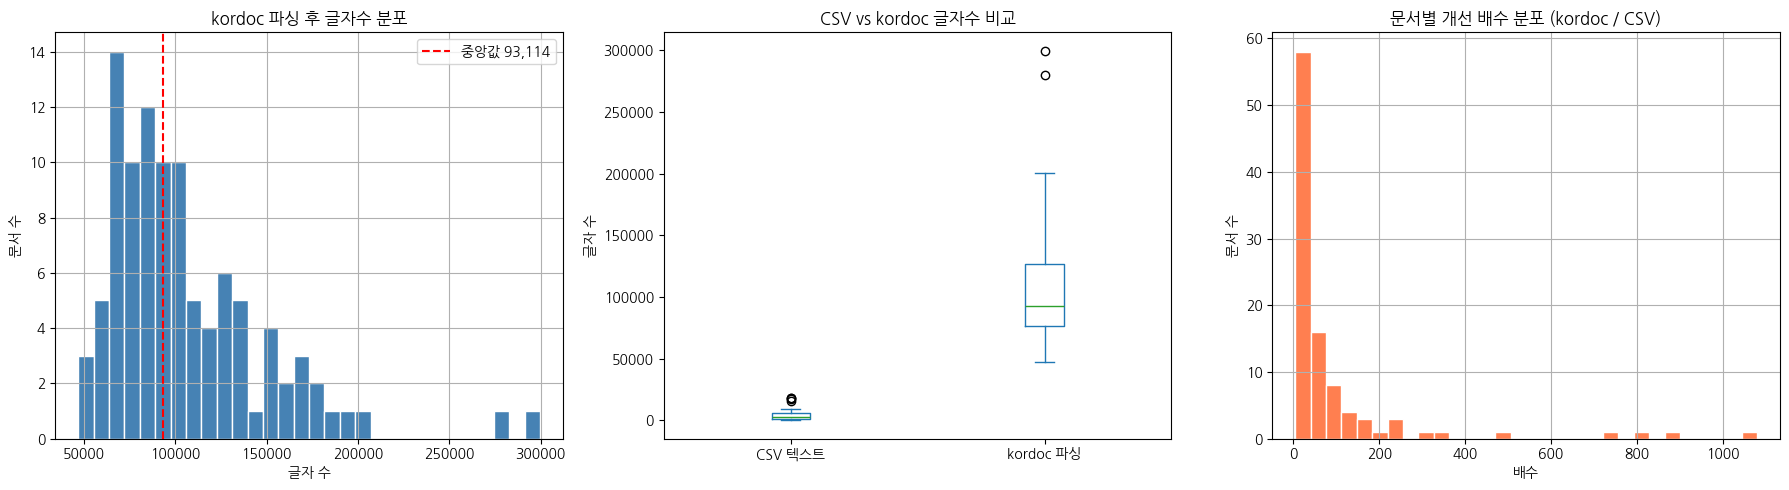

개선 배수 통계:
  평균: 93.5배
  중앙값: 35.8배
  최소: 4.3배
  최대: 1079.4배


In [16]:
import koreanize_matplotlib
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) 파싱 후 글자수 분포
kordoc_df['글자수'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('kordoc 파싱 후 글자수 분포')
axes[0].set_xlabel('글자 수')
axes[0].set_ylabel('문서 수')
axes[0].axvline(kordoc_df['글자수'].median(), color='red', linestyle='--', label=f'중앙값 {kordoc_df["글자수"].median():,.0f}')
axes[0].legend()

# 2) CSV vs kordoc 비교 (before/after)
csv_lens = df['텍스트'].fillna('').str.len()
compare_data = pd.DataFrame({
    'CSV 텍스트': csv_lens,
    'kordoc 파싱': kordoc_df.set_index('파일명')['글자수'].reindex(df['파일명']).values,
})
compare_data.plot.box(ax=axes[1], vert=True)
axes[1].set_title('CSV vs kordoc 글자수 비교')
axes[1].set_ylabel('글자 수')

# 3) 문서별 개선 배수 분포
csv_compare['배수'].hist(bins=30, ax=axes[2], color='coral', edgecolor='white')
axes[2].set_title('문서별 개선 배수 분포 (kordoc / CSV)')
axes[2].set_xlabel('배수')
axes[2].set_ylabel('문서 수')

plt.tight_layout()
plt.show()

print(f"개선 배수 통계:")
print(f"  평균: {csv_compare['배수'].mean():.1f}배")
print(f"  중앙값: {csv_compare['배수'].median():.1f}배")
print(f"  최소: {csv_compare['배수'].min():.1f}배")
print(f"  최대: {csv_compare['배수'].max():.1f}배")


## 11. 파일형식별 파싱 품질 비교

,문서 수,평균,중앙값,최소,최대
파일형식,,,,,
hwp,96,103995,92824,46953,299638
pdf,4,168276,162293,68336,280180


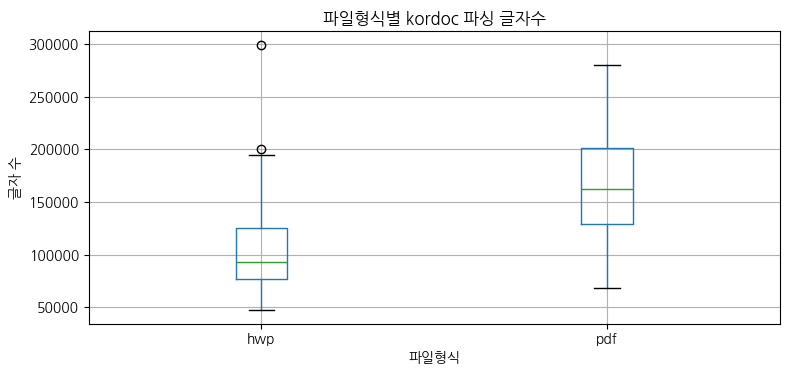

In [17]:
format_compare = df[['파일명', '파일형식']].merge(
    kordoc_df[['파일명', '글자수']], on='파일명', how='left'
)

format_stats = format_compare.groupby('파일형식')['글자수'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).round(0).astype(int)
format_stats.columns = ['문서 수', '평균', '중앙값', '최소', '최대']
display(format_stats)

fig, ax = plt.subplots(figsize=(8, 4))
format_compare.boxplot(column='글자수', by='파일형식', ax=ax)
ax.set_title('파일형식별 kordoc 파싱 글자수')
ax.set_ylabel('글자 수')
plt.suptitle('')
plt.tight_layout()
plt.show()


## 12. 파서 선정 의사결정 기록

### 검토한 파서

| 파서 | 언어 | HWP | PDF | DOCX | 출력 형식 | 비고 |
|---|---|---|---|---|---|---|
| **kordoc** | Node.js | O | O | O | 마크다운 | 표 파싱 우수, 한국 공공기관 실전 검증 |
| hwp-hwpx-parser | Python | O | X | X | 평문+표 객체 | 순수 Python, 목차 인코딩 깨짐 |
| pdfplumber | Python | X | O | X | 평문 | PDF 전용, CJK 지원 |

### 비교 테스트 결과 (국민연금공단 이러닝 문서)

| 항목 | kordoc | hwp-hwpx-parser | CSV 텍스트 |
|---|---|---|---|
| 글자수 | 81,459자 | 67,392자 | 2,346자 |
| 표 추출 | 마크다운 표 | 73개 TableData 객체 | 없음 |
| 목차 | 깔끔 | 인코딩 깨짐 (蛽ȃ 등) | 없음 |
| 구조 보존 | # 헤딩, 표 구조 | 평문 | 평문 |

### kordoc을 메인 파서로 선정한 이유

1. **마크다운 출력이 후처리 부담을 크게 줄임**: 제목(#), 표(|), 목차가 이미 구조화되어 정제 작업이 적음
2. **LLM 친화적**: 마크다운은 LLM이 가장 잘 이해하는 포맷이며, 청킹 시 # 기준 의미 단위 분할 가능
3. **표 보존 품질**: RFP의 핵심 정보(예산, 평가기준, 요구사항)가 표에 집중되므로 표 파싱 품질이 중요
4. **Node.js 의존성 부담이 낮음**: subprocess 호출 3줄로 파이프라인 통합 가능

### hwp-hwpx-parser를 교차 검증용으로 유지한 이유

- kordoc 실패 시 폴백 가능
- 글자수 비교로 누락 여부 확인 가능
- 순수 Python이므로 팀원 환경 호환성 보장

## 13. 요약

### 파싱 결과
- kordoc으로 **101건 전체 파싱 성공** (실패 0건)
- CSV 텍스트 대비 **평균 93.5배** 텍스트 추출 (3,844자 -> 106,566자)
- 마크다운 구조 (제목, 표, 목차) 보존

### CSV 텍스트의 한계
- 21건이 1,000자 미만으로 원본 내용의 3~5%만 담고 있었음
- 가장 극단적인 경우 89자 (원본 78,583자, **1,079배 차이**)
- CSV 텍스트만으로 RAG를 구축했다면 대부분의 질문에 답변 불가

### 파이프라인에 반영된 사항
| 의사결정 | 근거 |
|---|---|
| kordoc 메인 파서 선정 | 마크다운 출력 -> 정제/청킹 효율, 표 보존 품질 |
| 원본 재추출 필수 | CSV 텍스트는 3~5% 수준, 21건 1,000자 미만 |
| subprocess 기반 통합 | Node.js 의존성 최소화, 파일당 0.9초 처리 |
| 교차 검증 옵션 유지 | kordoc 실패 시 hwp-hwpx-parser 폴백 가능 |

### 저장된 파일
- `data/processed/parsed_documents.parquet`: 메타데이터 + 본문 마크다운 통합
- `data/processed/markdown/`: 문서별 개별 마크다운 파일

### 다음 단계
- `03_cleaning.ipynb`: 표 셀 중복 제거, kordoc Warning 제거, 공백 정규화
